# Adaptive optics loop data preprocessing for Machine Learning PSF Reconstruction (PSF-R-ML)

||||
|:---:|:---|:---|
|2026.04.10| Initial version | Dominique Humbert |




In [31]:
%matplotlib widget
import matplotlib.pyplot as plt
import h5py
import numpy as np
import pandas as pd
from matplotlib.patches import Circle


SMALL_SIZE = 20
MEDIUM_SIZE = 22
BIGGER_SIZE = 25
GPU = True
outputDir = "output/"
inputDir = "output/"

Parameters = "ao_metadata.txt"

diff_lim_file_name = "diff_lim_"

file_names = ["ao_DM_", "ao_lightfield_", "ao_psf_", "ao_rwfe_", "ao_WFS_"]

metadata = pd.read_csv(inputDir + Parameters, sep="\t", header=None, skiprows=1, index_col=0)
metadaty_keys = metadata.keys()
iterationPerBatch = int(metadata.loc["batchItSize"][1])
nActWSF = int(metadata.loc["nActWSF"][1])
edge_act = int(metadata.loc["edge_act"][1])
act_tot = nActWSF + 2*edge_act

In [4]:
print(iterationPerBatch)

NameError: name 'iterationPerBatch' is not defined

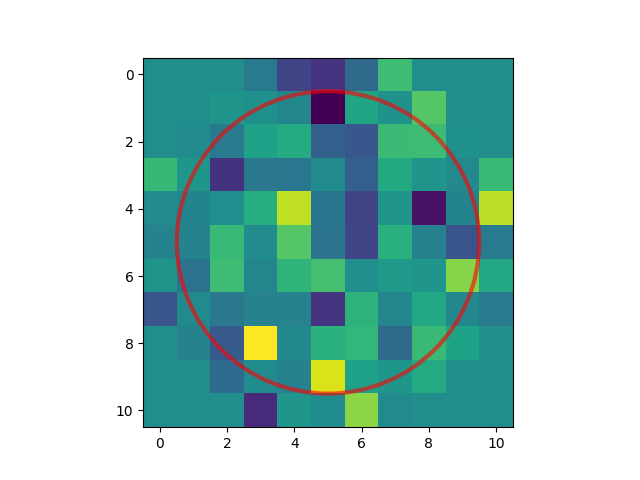

In [ ]:
temp = h5py.File(inputDir+"ao_DM_"+str(1)+".h5", 'r')
key = list(temp.keys())
ao_DM = temp[key[0]][()][0,:]

def circle_to_square(positions_1d, Nact1D=11):
    dm_array = np.zeros((Nact1D, Nact1D))
    y, x = np.ogrid[:Nact1D, :Nact1D]
    center = (Nact1D - 1) / 2
    dist_sq = (x - center)**2 + (y - center)**2
    # Get indices of N closest points to center
    sorted_indices = np.argsort(dist_sq.flatten())
    active_indices = sorted_indices[:len(positions_1d)]
    dm_array.flat[active_indices] = positions_1d
    return dm_array

dm_array = circle_to_square(ao_DM, Nact1D=act_tot)


plt.close(0)
plt.figure(0)
plt.imshow(dm_array)
circle = Circle((5, 5), 4.5, color='red', fill=False, linewidth=3,alpha=0.6)
plt.gca().add_patch(circle)

In [ ]:
temp = h5py.File(inputDir+"ao_rwfe_"+str(1)+".h5", 'r')
key = list(temp.keys())
ao_RWFE = temp[key[0]][()]
print(ao_RWFE[0])


[4.77168610e-01 1.45253847e+06 4.81350776e+06 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


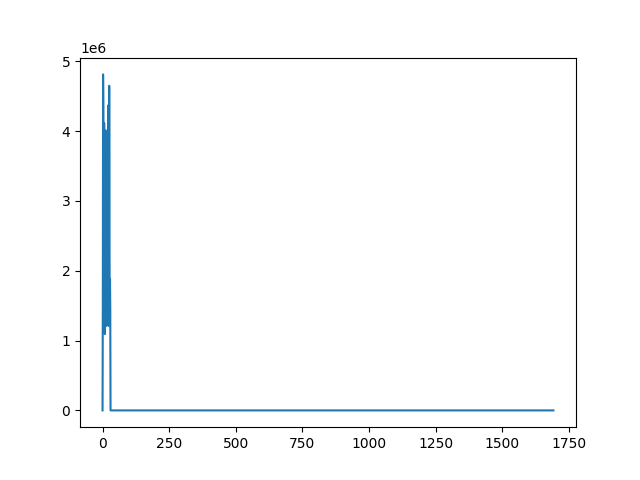

In [ ]:
plt.close(0)
plt.figure(0)
plt.plot(ao_RWFE[0])
plt.show()


## Load datasets

In [ ]:


# for file_name in file_names:  
#     if file_name == file_names[0]:
#         for i in range(1, 5+1):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_DM = temp[key[0]][()]
#     elif file_name == file_names[1]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_lightfield = temp[key[0]][()]
#     elif file_name == file_names[2]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_psf = temp[key[0]][()]
#     elif file_name == file_names[3]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_rwfe = temp[key[0]][()]
#     elif file_name == file_names[4]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_WFS = temp[key[0]][()]




# temp = h5py.File(inputDir+"ao_diff_limited_.h5", 'r')
# key = list(temp.keys())
# diff_lim = temp[key[0]][()]

# plt.close(0)
# plt.figure()
# plt.imshow(diff_lim**(1/2))

In [ ]:
# # print(ao_DM.shape)
# plt.close(0)
# plt.figure(0)
# plt.imshow(ao_DM[60,:].reshape(11,11))
# circle = Circle((5, 5), 4.5, color='red', fill=False, linewidth=3,alpha=0.6)
# plt.gca().add_patch(circle)


# print(ao_lightfield.shape)
# # print(ao_DM[:,0])
# plt.close(1)
# plt.figure(1)
# plt.imshow(ao_lightfield[50,:,:]**(1/4))

# print(ao_psf.shape)
# # print(ao_DM[:,0])
# plt.close(2)
# plt.figure(2)
# plt.imshow(ao_psf[88,:,:])
